# 1. Limits and continuity

Calculus begins by asking what happens as an input approaches a point, even when substituting that exact point is impossible. You will distinguish nearby behavior from a function's value, compute two-sided and one-sided examples, identify removable holes and jumps, and explain why numerical experiments are evidence rather than proofs. Prerequisites: [functions and graphs](../../../02_Mathematics_for_ML/04_functions_and_graphs.ipynb), fractions, and elementary algebra. All inputs and outputs are dimensionless unless an analogy explicitly supplies units.

## 2. What problem does this solve?

A rate of change often involves dividing an output change by an input change. At exactly zero input change, direct division fails. We instead study what happens for smaller and smaller nonzero changes. Limits make that question precise and will support the derivative lesson next. Continuity asks whether a function's value agrees with its nearby behavior. These concepts also explain why some numerical calculations suddenly fail near otherwise ordinary inputs.

## 3. Intuition and analogy

Imagine approaching a bridge from either bank. Both approaches may lead to the same location even if one paving stone is missing at that location. That resembles a removable hole. If the two banks terminate at different heights, the left and right approaches disagree, resembling a jump. The location reached by approaching is separate from whether a stone is actually present. A limit describes the approach; a function value describes the exact input.

## 4. Terminology

A domain is the set of permitted inputs. A limit is a value approached by outputs as inputs approach a specified point. A left-hand limit approaches through smaller inputs; a right-hand limit approaches through larger ones. A finite two-sided limit exists when both one-sided limits agree. A function is continuous at a point when it is defined there, has a limit there, and its value equals that limit. A removable discontinuity can be repaired by defining or changing one value. A jump cannot be repaired by changing only its value at the jump point.

## 5. Mathematical foundations

The notation
\[
\lim_{x\to a}f(x)=L
\]
means outputs f(x) approach L as x approaches a, while x need not equal a. Here x is the variable input, a is the approached input, f is the rule, and L is the proposed limiting output. Continuity additionally requires f(a)=L.

For a precise finite limit, every output tolerance \(\varepsilon>0\) must admit an input tolerance \(\delta>0\) such that
\[
0<|x-a|<\delta\quad\Rightarrow\quad|f(x)-L|<\varepsilon.
\]
The Greek letters epsilon and delta name positive tolerances. Epsilon has output units and delta input units if units apply. The strict lower bound excludes x=a, so a hole at the approached point does not by itself prevent a limit. Every sufficiently close permitted input must satisfy the bound; testing a few selected inputs is weaker.

For f(x)=2x+1 at a=1, L=3 and |f(x)-3|=2|x-1|. Given any epsilon, choosing delta=epsilon/2 guarantees the required bound. This algebra supplies a proof for all sufficiently nearby real inputs, rather than a numerical guess.

## 6. Hand-calculated example

Consider g(x)=(x^2-1)/(x-1), defined for x not equal to 1. Factoring gives (x-1)(x+1)/(x-1)=x+1 on that domain. At x=.9, g=1.9; at 1.1, g=2.1. At .99 and 1.01, outputs are 1.99 and 2.01. Both sides approach 2. Yet the original expression is undefined at 1 because it would divide zero by zero. Defining a new function h(1)=2 and h(x)=g(x) elsewhere fills the hole continuously. Assigning h(1)=7 instead leaves the same limit but a discontinuity.

## 7. Scratch approach experiment

The plain-Python loop constructs shrinking positive distances by halving each time. `for` repeats the calculation, and tuples store paired left/right results. We evaluate the algebraically simplified rule away from the hole, preserving the original domain explicitly. This mechanism generates evidence of approach, not a general symbolic limit solver.

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
def original_domain_simplified(x):
    if x == 1:
        raise ValueError('The original function excludes x=1.')
    return x + 1

def approach_table(steps):
    rows = []
    for step in range(1, steps + 1):
        distance = 2.0 ** (-step)
        left, right = 1-distance, 1+distance
        rows.append((distance, original_domain_simplified(left),
                     original_domain_simplified(right)))
    return rows

table = approach_table(8)
assert table[0] == (.5, 1.5, 2.5)
assert table[-1][1:] == (1.99609375, 2.00390625)
print('Distance, left output, right output:')
for row in table:
    print(row)

Distance, left output, right output:
(0.5, 1.5, 2.5)
(0.25, 1.75, 2.25)
(0.125, 1.875, 2.125)
(0.0625, 1.9375, 2.0625)
(0.03125, 1.96875, 2.03125)
(0.015625, 1.984375, 2.015625)
(0.0078125, 1.9921875, 2.0078125)
(0.00390625, 1.99609375, 2.00390625)


## 8. Inspecting intermediate behavior

The output discrepancy is exactly the input discrepancy for this example. A jump behaves differently: define s(x)=0 for negative x and 1 otherwise. At any negative approaching input the output remains 0; at any positive approaching input it remains 1. Choosing s(0)=0, 1, or any other number cannot make these different one-sided limits agree.

In [3]:
def step_function(x):
    return 0 if x < 0 else 1

for distance, left, right in table:
    assert abs(left-2) == distance
    assert abs(right-2) == distance
    assert step_function(-distance) == 0
    assert step_function(distance) == 1
print('Jump left/right outputs:', step_function(-1e-6), step_function(1e-6))
try:
    original_domain_simplified(1)
except ValueError:
    print('Hole correctly retained in the original domain.')
else:
    raise AssertionError('Undefined input was accepted.')

Jump left/right outputs: 0 1
Hole correctly retained in the original domain.


## 9. NumPy implementation and its limits

NumPy applies formulas to arrays of nearby inputs efficiently. It is a numerical array library, not a symbolic theorem prover. We need no additional package to reproduce our calculations; the mathematical factorization already establishes the result. `np.where` selects output values according to a condition, producing a vectorized step function. Do not assume numerical convergence alone establishes a limit for every possible approach.

In [4]:
import numpy as np
distances = 10.0 ** (-np.arange(1, 7))
left_inputs = 1-distances
right_inputs = 1+distances
left_outputs = left_inputs+1
right_outputs = right_inputs+1
assert np.allclose(left_outputs, 2-distances)
assert np.allclose(right_outputs, 2+distances)
assert np.array_equal(np.where(np.array([-.1, .1]) < 0, 0, 1), [0, 1])
print('Smallest tested left/right outputs:', left_outputs[-1], right_outputs[-1])

Smallest tested left/right outputs: 1.9999989999999999 2.000001


## 10. Visualization

The left graph marks the hole using an unfilled circle, and an alternative value of 7 using a filled point. The curve still approaches 2. The right graph has incompatible left and right limiting levels. Markers explicitly distinguish excluded endpoints from assigned values, which a line plot alone would hide. The plotted gap around each point is a drawing choice, not an interval removed from the mathematical domain.

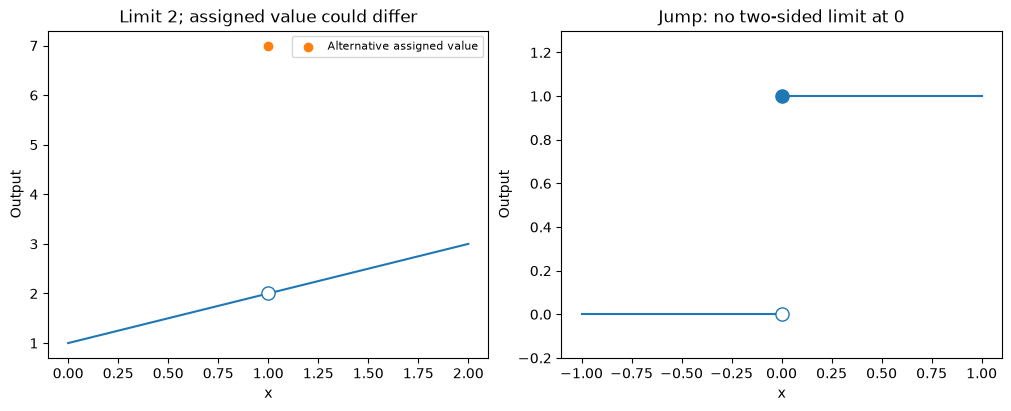

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for inputs in [np.linspace(0, .99, 100), np.linspace(1.01, 2, 100)]:
    axes[0].plot(inputs, inputs+1, color='tab:blue')
axes[0].scatter([1], [2], facecolors='white', edgecolors='tab:blue', s=90, zorder=3)
axes[0].scatter([1], [7], color='tab:orange', label='Alternative assigned value', zorder=3)
axes[0].set(title='Limit 2; assigned value could differ', xlabel='x', ylabel='Output')
axes[0].legend(fontsize=8)
axes[1].plot([-1, 0], [0, 0], color='tab:blue')
axes[1].plot([0, 1], [1, 1], color='tab:blue')
axes[1].scatter([0], [0], facecolors='white', edgecolors='tab:blue', s=90, zorder=3)
axes[1].scatter([0], [1], color='tab:blue', s=90, zorder=3)
axes[1].set(title='Jump: no two-sided limit at 0', xlabel='x', ylabel='Output', ylim=(-.2, 1.3))
display(fig)
plt.close(fig)

## 11. A numerical-precision experiment

Near x=1, directly subtracting almost equal numbers in x^2-1 loses significant digits. This is cancellation. With a small enough offset, floating-point storage rounds 1+offset to exactly 1, and the original denominator becomes zero. Smaller steps therefore do not always produce better calculations. Algebraic simplification evaluates nearby outputs more reliably, but it must not silently redefine the original domain.

In [6]:
for offset in [1e-4, 1e-8, 1e-12, 1e-16]:
    x = 1.0 + offset
    if x == 1.0:
        print('Requested offset rounded away:', offset)
        continue
    direct = (x*x-1)/(x-1)
    simplified = x+1
    print('Offset, direct, simplified, difference:',
          offset, direct, simplified, abs(direct-simplified))
assert 1.0 + 1e-16 == 1.0
assert np.isclose((1.1**2-1)/(1.1-1), 2.1)

Offset, direct, simplified, difference: 0.0001 2.0000999999993923 2.0000999999999998 6.075140390748857e-13
Offset, direct, simplified, difference: 1e-08 2.0 2.00000001 9.99999993922529e-09
Offset, direct, simplified, difference: 1e-12 2.0 2.000000000001 1.000088900582341e-12
Requested offset rounded away: 1e-16


## 12. Numerical choices, not learned parameters

Step size, number of samples, and output tolerance are chosen inspection settings. No model weights are trained. A mathematical limit is independent of our chosen finite table, whereas numerical estimates depend on representable inputs and arithmetic. For the linear proof, epsilon is an arbitrary requested output accuracy and delta is selected to guarantee it. They are not random noise levels or optimizer learning rates.

## 13. Evaluation

Use algebra to justify the limit when possible, then check numerical examples for consistency. Test both sides of an interior point. Check the function's domain separately from its limit. Our linear delta guarantee can be sampled below as an illustration, but its proof was the inequality in section 5. Finite plots can miss narrow oscillations or behavior between samples, so never describe a graph alone as proving continuity.

In [7]:
epsilon = .1
delta = epsilon/2
nearby = 1 + delta*np.array([-.99, -.5, .5, .99])
assert np.all(np.abs(nearby-1) < delta)
assert np.all(np.abs((2*nearby+1)-3) < epsilon)
print('Output discrepancies inside chosen delta:', np.abs((2*nearby+1)-3))

Output discrepancies inside chosen delta: [0.099 0.05  0.05  0.099]


## 14. Assumptions and limitations

We focus on finite real limits of elementary functions at interior points. Limits at infinity, divergence to infinity, and oscillatory examples need additional discussion. Continuity does not guarantee differentiability: absolute value is continuous at zero but has a corner. A derivative asks for the limit of a difference quotient, a stronger condition than merely matching nearby function values.

## 15. Common mistakes and debugging

Zero divided by zero is not zero and does not itself determine the limit. A missing function value does not automatically destroy the limit. Agreement from only one side is insufficient for a two-sided claim. Oversampling closer to a point may amplify rounding problems. Check domain exclusions and compare an equivalent simplified expression before diagnosing a surprising table as new mathematics.

## 16. Connections and alternatives

Direct substitution works for continuous expressions at allowed points. Factoring can reveal a removable discontinuity. One-sided analysis identifies jumps. Symbolic tools can assist algebra but do not replace knowing assumptions and domains; none is required here. In optimization, continuous losses can still have corners, and discrete threshold predictions can jump even when underlying scores vary smoothly. Later lessons distinguish these cases carefully.

## 17. Exercises

1. **Beginner:** Find the limit of 3x+2 as x approaches 2.
2. **Beginner:** Does redefining g(1)=7 change the limit of our hole example?
3. **Beginner:** State the left and right limits of the step function at zero.
4. **Intermediate:** Choose delta for f(x)=3x+2 at a=2 with requested epsilon=.06.
5. **Intermediate:** Simplify (x^2-4)/(x-2), state its domain exclusion, and find its limit at 2.
6. **Challenge:** Explain why sampling sin(1/x) only at x=1/(n*pi) could misleadingly suggest a zero limit as x approaches zero.

## 18. Worked solutions

1. Substitution gives 3(2)+2=8; a linear function is continuous everywhere on the real line.
2. No. Nearby outputs still approach 2. The changed function is not continuous because its value 7 disagrees with that limit.
3. Left limit is 0 and right limit is 1, so no common two-sided limit exists.
4. |f(x)-8|=3|x-2|. Choose delta=.06/3=.02. For strictly smaller input discrepancies, output discrepancies are strictly below .06.
5. Factor (x-2)(x+2), then cancel only for x not equal to 2. The limiting value is 4, and the original expression remains undefined at 2.
6. For positive integer n, those selected inputs make 1/x=n*pi and sine zero. But inputs 1/(pi/2+2n*pi) also approach zero and give sine one. Other inputs give minus one. The incompatible approaching sequences rule out a single limit. A finite floating-point implementation produces approximate, not exact, zeros and ones.

In [8]:
assert 3*2+2 == 8
assert np.isclose(.06/3, .02)
for x in [1.9, 2.1]:
    assert np.isclose((x*x-4)/(x-2), x+2)
n = np.arange(1, 11)
zero_sequence = 1/(n*np.pi)
one_sequence = 1/(np.pi/2 + 2*n*np.pi)
assert np.allclose(np.sin(1/zero_sequence), 0, atol=1e-12)
assert np.allclose(np.sin(1/one_sequence), 1)

## 19. Knowledge check

**Must f(a) exist for a limit to exist?** No; a removable hole provides a counterexample.

**What additional requirement makes the function continuous?** Its defined value must equal its limit.

**Does a jump have a finite two-sided limit?** No when its finite one-sided limits differ.

**Does closer always mean numerically more accurate?** No; rounding and cancellation can become worse.

**Does continuity guarantee a derivative?** No; a continuous corner can have incompatible one-sided slopes.

## 20. Interview preparation

**Why do limits matter for gradients?** Derivatives use limits of output-change divided by input-change.

**Why separate domain from algebraic simplification?** Cancelling factors can hide excluded inputs and incorrectly redefine the function.

**What is cancellation error?** Subtracting nearly equal represented quantities can lose relative precision in the small result.

**Why are finite convergence tables not proofs?** They inspect selected points rather than every sufficiently nearby allowed input.

**What distinguishes a removable hole from a jump?** Matching one-sided limits permit a single-value repair; incompatible one-sided limits do not.

## 21. Summary and next steps

Limits describe nearby behavior; continuity additionally connects that behavior to the exact function value. Algebra and domain checks support conclusions that plots alone cannot prove. Continue to [derivatives](../../../02_Mathematics_for_ML/README.md#02-18), currently planned, to formalize instantaneous rates of change.